In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
####################################
from matplotlib import pyplot as plt
from matplotlib import patches, cm, colors
from matplotlib import patheffects as pe
import matplotlib.ticker as ticker
from matplotlib.transforms import ScaledTranslation
from matplotlib.markers import MarkerStyle

In [2]:
plt.rcParams.update({"figure.facecolor":(1.0, 1.0, 1.0, 0.0),
                     "axes.facecolor":(1.0, 1.0, 1.0, 1.0)})
plt.rcParams["font.family"] = 'Helvetica'
plt.rcParams["font.size"] = 30
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.it'] = 'Helvetica'
plt.rcParams['mathtext.rm'] = 'Helvetica'
plt.rcParams['figure.figsize'] = (10,8)

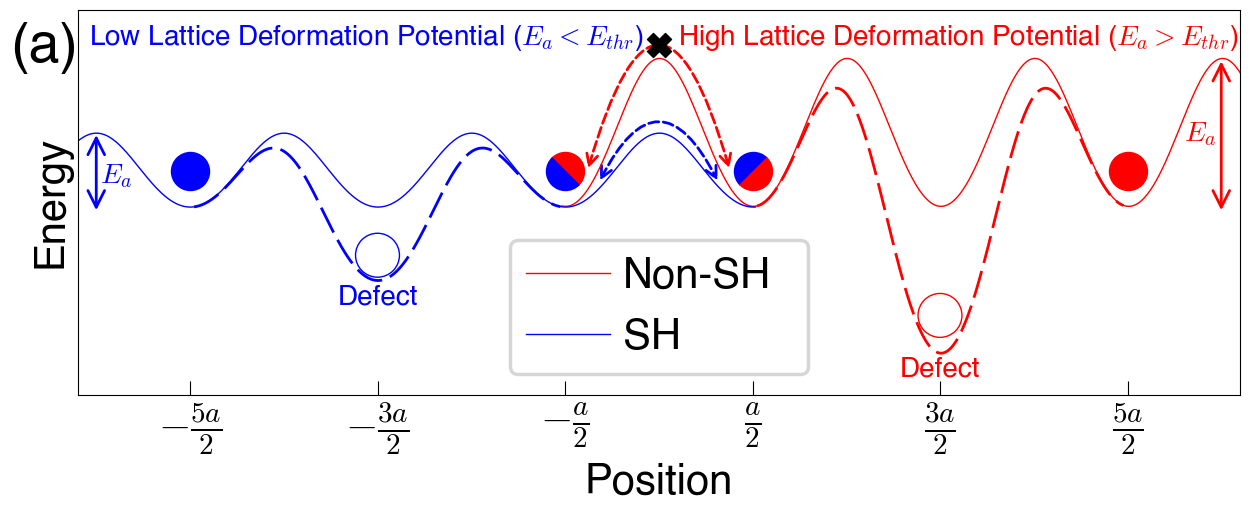

In [3]:
fig = plt.figure(figsize=(15,5))
y1 = np.zeros(1000)
y1d = np.zeros(1000)

y2 = np.zeros(1000)
y2d = np.zeros(1000)

x = np.linspace(-1,1,1000)
x_ = np.linspace(-1,1,125)
for k in range(8):
    y1[125*k:125*(k+1)] += x_**2
    y1d[125*k:125*(k+1)] += (1+0.5*int(k==5))*x_**2-0.5*int(k==5)
    y2[125*k:125*(k+1)] += 0.5*x_**2-0.5
    y2d[125*k:125*(k+1)] += (1+0.5*int(k==2))*0.5*x_**2-0.5*0.5*int(k==2)

g = np.exp(-x**2*250)
y1 = np.convolve(y1, g, mode='same')
y2 = np.convolve(y2, g, mode='same')
y1d = np.convolve(y1d, g, mode='same')
y2d = np.convolve(y2d, g, mode='same')

y1r = y1[435:]-np.mean(y1[125:500])
y1dr = y1d[565:810]-np.mean(y1d[125:500])
plt.plot(x[435:], y1r - np.min(y1r), c='red', linewidth=1, label='Non-SH')
plt.plot(x[565:810], y1dr - np.min(y1r), c='red', linewidth=2, linestyle=(0, (10, 3)))

y2b = y2[:565]-np.mean(y2[500:875])
y2db = y2d[190:435]-np.mean(y2d[500:875])
plt.plot(x[:565], y2b-np.min(y2b), c='blue', linewidth=1, label='SH')
plt.plot(x[190:435], y2db-np.min(y2b), c='blue', linewidth=2, linestyle=(0, (10, 3)))

plt.scatter([-0.625], [6], c='blue', s=750)
plt.scatter([-0.625+5*0.25], [6], c='red', s=750)

plt.scatter([-0.625+0.5], [6], s=750, marker=MarkerStyle('o', fillstyle='right').rotated(deg=45), color='red')
plt.scatter([-0.625+0.5], [6], s=750, marker=MarkerStyle('o', fillstyle='left').rotated(deg=45), color='blue')

plt.scatter([-0.625+0.75], [6], s=750, marker=MarkerStyle('o', fillstyle='right').rotated(deg=135), color='blue')
plt.scatter([-0.625+0.75], [6], s=750, marker=MarkerStyle('o', fillstyle='left').rotated(deg=135), color='red')

plt.scatter([-0.625+0.25], [-8], c='none', edgecolor='blue', s=1000)
plt.scatter([-0.625+4*0.25], [-18], c='none', edgecolor='red', s=1000)

plt.annotate('', xy=(0.75, -1), xytext=(0.75, max(y1r)-min(y1r)),
                arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='<->', linewidth=2))
plt.annotate('', xy=(-0.75, -1), xytext=(-0.75, max(y2b)),
                arrowprops=dict(facecolor='red', edgecolor='blue', arrowstyle='<->', linewidth=2))

plt.annotate('High Lattice Deformation Potential ($E_{a}>E_{thr}$)', (0.025,27), fontsize=20, c='red')
plt.annotate('Low Lattice Deformation Potential ($E_{a}<E_{thr}$)', (-0.76,27), fontsize=20, c='blue')
plt.annotate('Defect', (-0.625+0.25, -15), fontsize=20, ha='center', va='center', c='blue')
plt.annotate('Defect', (-0.625+4*0.25, -27), fontsize=20, ha='center', va='center', c='red')
plt.annotate('$E_{a}$', (0.7, 11), fontsize=20, c='red')
plt.annotate('$E_{a}$', (-0.745, 4), fontsize=20, c='blue')

plt.xlim([-0.775, 0.775])
plt.ylim([min(y1dr)+5, max(y1r) + 20])

plt.xticks([-0.625+0.25*k for k in range(6)], labels=['$-\\frac{5a}{2}$', '$-\\frac{3a}{2}$', '$-\\frac{a}{2}$',
                                                      '$\\frac{a}{2}$', '$\\frac{3a}{2}$', '$\\frac{5a}{2}$'])
plt.yticks([])

plt.gca().add_patch(patches.FancyArrowPatch(posA=[-0.08,4], posB=[0.08,4],connectionstyle="arc3,rad=-1",  # curvature (positive = CCW, negative = CW)
    arrowstyle="<->,head_length=8,head_width=4",color="blue",linewidth=2, linestyle='--'))

plt.gca().add_patch(patches.FancyArrowPatch(posA=[-0.095,6], posB=[0.095,6],connectionstyle="arc3,rad=-1.75",  # curvature (positive = CCW, negative = CW)
    arrowstyle="<->,head_length=8,head_width=4",color="red",linewidth=2, linestyle='--'))

plt.scatter([0], [27], marker='X', c='k', s=300)

fig.text(0.08,0.775, "(a)", fontsize=40)

leg = plt.legend()
for text, label in zip(leg.get_texts(), ['Non-SH', 'SH']):
    text.set_position((-20, 0))
leg.get_frame().set_linewidth(2.5)
plt.xlabel('Position')
plt.ylabel('Energy')
plt.tick_params(direction='in', length=10, axis='x')
plt.savefig('Figures/Figure1a.pdf', bbox_inches="tight", pad_inches=0.1)
plt.savefig('Figures/Figure1a.png', bbox_inches="tight", pad_inches=0.1)

plt.show()

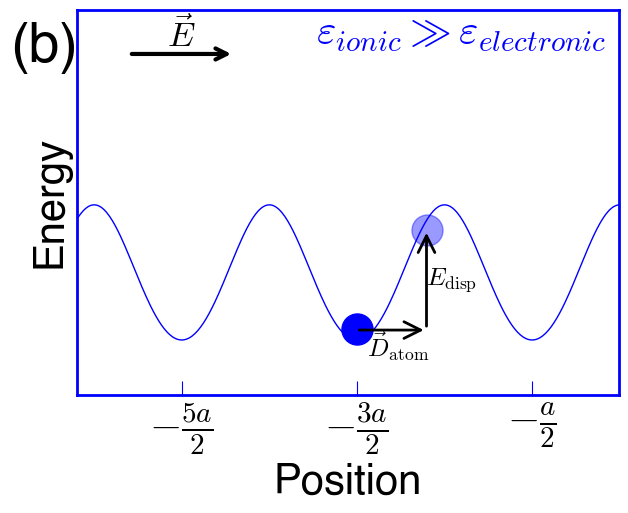

In [4]:
fig=plt.figure(figsize=(7,5))
y2 = np.zeros(1000)

x = np.linspace(-1,1,1000)
x_ = np.linspace(-1,1,125)
for k in range(8):
    y2[125*k:125*(k+1)] += 0.5*x_**2-0.5

g = np.exp(-x**2*250)
y2 = np.convolve(y2, g, mode='same')

#y2r = y2[125:875]-np.mean(y2)
#plt.plot(x[125:875], y2r - np.min(y2r), c='blue', linewidth=1)
y2b = y2[:565]-np.mean(y2[500:875])
plt.plot(x[:565], y2b-np.min(y2b), c='blue', linewidth=1)

plt.xlim([-0.775, 0])
plt.ylim([-5, 30])

plt.xticks([-0.625+0.25*k for k in range(6)][:3], labels=['$-\\frac{5a}{2}$', '$-\\frac{3a}{2}$', '$-\\frac{a}{2}$',
                                                      '$\\frac{a}{2}$', '$\\frac{3a}{2}$', '$\\frac{5a}{2}$'][:3])
plt.yticks([])

plt.gca().add_patch(patches.FancyArrowPatch(posA=[-0.7,26], posB=[-0.55,26], arrowstyle="->,head_length=8,head_width=4",color="k",linewidth=3))
plt.annotate('$\\vec{E}$', (-0.625, 26), ha='center', va='bottom', fontsize=25)
plt.annotate('$\\varepsilon_{ionic} \\gg \\varepsilon_{electronic}$', (-0.225, 26), ha='center', va='bottom', fontsize=30, color='blue')
plt.scatter([-0.625+0.25], [1], c='blue', edgecolor='blue', s=500)
plt.scatter([-0.625+0.25+0.1], [10], c='blue', edgecolor='blue', s=500, alpha=0.4)

plt.annotate('', xy=(-0.625+0.25+0.1, 0.9), xytext=(-0.625+0.25, 0.9),
                arrowprops=dict(facecolor='k', edgecolor='k', arrowstyle='->', linewidth=2))

plt.annotate('$\\vec{D}_{\\text{atom}}$', (-0.625+0.25+0.06, 0.9), ha='center', va='top', fontsize=18)

plt.annotate('', xy=(-0.625+0.25+0.1, 10), xytext=(-0.625+0.25+0.1, 1),
                arrowprops=dict(facecolor='k', edgecolor='k', arrowstyle='->', linewidth=2))
plt.annotate('$E_{\\text{disp}}$', (-0.625+0.25+0.1, 5), fontsize=18)

#plt.axhline(y=10, c='k', linestyle='--', linewidth=1)
#plt.gca().add_patch(patches.FancyArrowPatch(posA=[-0.35,1.5], posB=[-0.15,1.5],connectionstyle="arc3,rad=-1.8", 
#    arrowstyle="<->,head_length=8,head_width=4",color="blue",linewidth=2, linestyle='--'))


fig.text(0.03,0.775, "(b)", fontsize=40)

#leg = plt.legend(fontsize=20, bbox_to_anchor=(0.55,0.5))
#for text, label in zip(leg.get_texts(), ['SH', 'SH under $\\vec{E}$']):
#    text.set_position((-20, 0))
#leg.get_frame().set_linewidth(2.5)
plt.xlabel('Position')
plt.ylabel('Energy')
plt.setp(plt.gca().spines.values(), lw=2, color='blue')
plt.tick_params(direction='in', length=10, axis='x', color='blue')
plt.savefig('Figures/Figure1b.pdf', bbox_inches="tight", pad_inches=0.1)
plt.savefig('Figures/Figure1b.png', bbox_inches="tight", pad_inches=0.1)

plt.show()

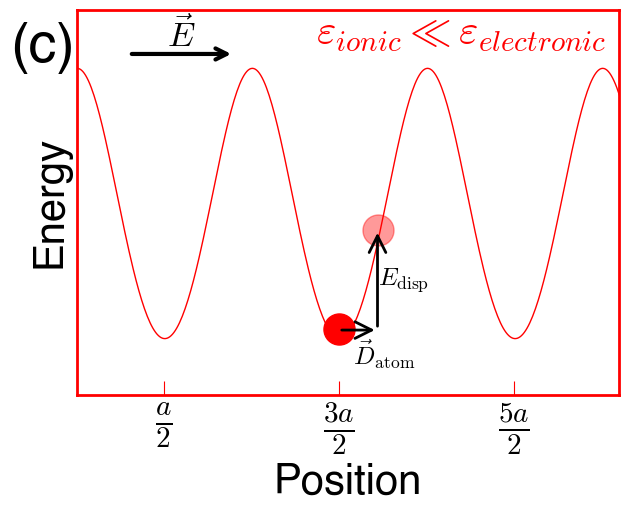

In [5]:
fig=plt.figure(figsize=(7,5))
y1 = np.zeros(1000)

x = np.linspace(-1,1,1000)
x_ = np.linspace(-1,1,125)
for k in range(8):
    y1[125*k:125*(k+1)] += x_**2

g = np.exp(-x**2*250)
y1 = np.convolve(y1, g, mode='same')

#y1r = y1[125:875]-np.mean(y1)
#plt.plot(x[125:875], y1r - np.min(y1r), c='red', linewidth=1)

y1r = y1[435:]-np.mean(y1[125:500])
plt.plot(x[:565]-x[0]+x[435], y1r - np.min(y1r), c='red', linewidth=1)#, label='No $\\vec{E}$')
#plt.plot(x[10:575]-x[0]+x[435], y1r-np.min(y1r), c='red', linewidth=1, linestyle='--', label='Under $\\vec{E}$')


plt.xlim([0, 0.775])
plt.ylim([-5, 30])

plt.xticks([-0.625+0.25*k for k in range(6)[3:]], labels=['$-\\frac{5a}{2}$', '$-\\frac{3a}{2}$', '$-\\frac{a}{2}$',
                                                      '$\\frac{a}{2}$', '$\\frac{3a}{2}$', '$\\frac{5a}{2}$'][3:])
plt.yticks([])

plt.gca().add_patch(patches.FancyArrowPatch(posA=[0.075,26], posB=[0.225,26], arrowstyle="->,head_length=8,head_width=4",color="k",linewidth=3))
plt.annotate('$\\vec{E}$', (0.15, 26), ha='center', va='bottom', fontsize=25)
plt.annotate('$\\varepsilon_{ionic} \\ll \\varepsilon_{electronic}$', (0.55, 26), ha='center', va='bottom', fontsize=30, color='r')
plt.scatter([0.625-0.25], [1], c='red', edgecolor='red', s=500)
plt.scatter([0.625-0.25+0.055], [10], c='red', edgecolor='red', s=500, alpha=0.4)


plt.annotate('', xy=(0.625-0.25+0.055, 0.9), xytext=(0.625-0.25, 0.9),
                arrowprops=dict(facecolor='k', edgecolor='k', arrowstyle='->', linewidth=2))

plt.annotate('$\\vec{D}_{\\text{atom}}$', (0.625-0.25+0.065, 0.2), ha='center', va='top', fontsize=18)

plt.annotate('', xy=(0.625-0.25+0.055, 10), xytext=(0.625-0.25+0.055, 1),
                arrowprops=dict(facecolor='k', edgecolor='k', arrowstyle='->', linewidth=2))
plt.annotate('$E_{\\text{disp}}$', (0.625-0.25+0.055, 5), fontsize=18)

#plt.gca().add_patch(patches.FancyArrowPatch(posA=[0.41,6.4], posB=[0.59,6.4],connectionstyle="arc3,rad=-3.3",
#    arrowstyle="<->,head_length=8,head_width=4",color="red",linewidth=2, linestyle='--'))
#plt.axhline(y=10, c='k', linestyle='--', linewidth=1)
#plt.scatter([0.5], [25.1], marker='X', c='k', s=300, zorder=1000)
fig.text(0.03,0.775, "(c)", fontsize=40)
#leg = plt.legend(fontsize=20, loc='lower left', bbox_to_anchor=(0.55,0.5))
#for text, label in zip(leg.get_texts(), ['No $\\vec{E}$', 'Under $\\vec{E}$']):
#    text.set_position((-20, 0))
#leg.get_frame().set_linewidth(2.5)

plt.xlabel('Position')
plt.ylabel('Energy')
plt.setp(plt.gca().spines.values(), lw=2, color='red')
plt.tick_params(direction='in', length=10, axis='x', color='red')
plt.savefig('Figures/Figure1c.pdf', bbox_inches="tight", pad_inches=0.1)
plt.savefig('Figures/Figure1c.png', bbox_inches="tight", pad_inches=0.1)

plt.show()